<a href="https://colab.research.google.com/github/bilal2343/machine-learning/blob/main/Hypertension_Part1_EDA_SIMPLE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Part 1: EDA - Simple Version

**Hypertension Risk Prediction**

**Step 1: Load Libraries**

In [1]:
# Import tools we need
import pandas as pd  # For working with data tables
import numpy as np   # For working with numbers
import matplotlib.pyplot as plt  # For making charts
import seaborn as sns  # For making pretty charts

# Project settings
RANDOM_SEED = 42
TARGET_COLUMN = "Hypertension"  # What we want to predict

# Make charts look nice
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("husl")

print("✓ Libraries loaded")

✓ Libraries loaded


**Step 2: Load Data**

In [2]:
# Load the data file
df = pd.read_csv("hypertension_dataset.csv")

print(f"✓ Data loaded")
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

✓ Data loaded
Number of rows: 9667
Number of columns: 23


**Step 3: Check Data Quality**

In [3]:
# Step 3a: Check for duplicate rows (same person appearing twice)
duplicates = df.duplicated().sum()
print(f"Duplicate rows: {duplicates}")

# Step 3b: Check for missing values (empty cells)
missing = df.isnull().sum()
total_missing = missing.sum()

if total_missing == 0:
    print("✓ No missing values")
else:
    print(f"\nMissing values found:")
    print(missing[missing > 0].to_string())

Duplicate rows: 0

Missing values found:
Cholesterol                1
Systolic_BP                1
Diastolic_BP               1
Smoking_Status             1
Alcohol_Intake             1
Physical_Activity_Level    1
Family_History             1
Diabetes                   1
Stress_Level               1
Salt_Intake                1
Sleep_Duration             1
Heart_Rate                 1
LDL                        1
HDL                        1
Triglycerides              1
Glucose                    1
Gender                     1
Education_Level            1
Employment_Status          1
Hypertension               1


**Step 4: Class Distribution (How many people have hypertension?)**

In [4]:
# Count people in each group
counts = df[TARGET_COLUMN].value_counts().sort_index()

print("Number of people in each group:")
for group, count in counts.items():
    print(f"  {group}: {count} people")

# Show as percentages
pcts = df[TARGET_COLUMN].value_counts(normalize=True).sort_index() * 100
print("\nAs percentages:")
for group, pct in pcts.items():
    print(f"  {group}: {pct:.1f}%")

Number of people in each group:
  High: 7021 people
  Low: 2645 people

As percentages:
  High: 72.6%
  Low: 27.4%


**Step 5: Visualize Class Distribution**

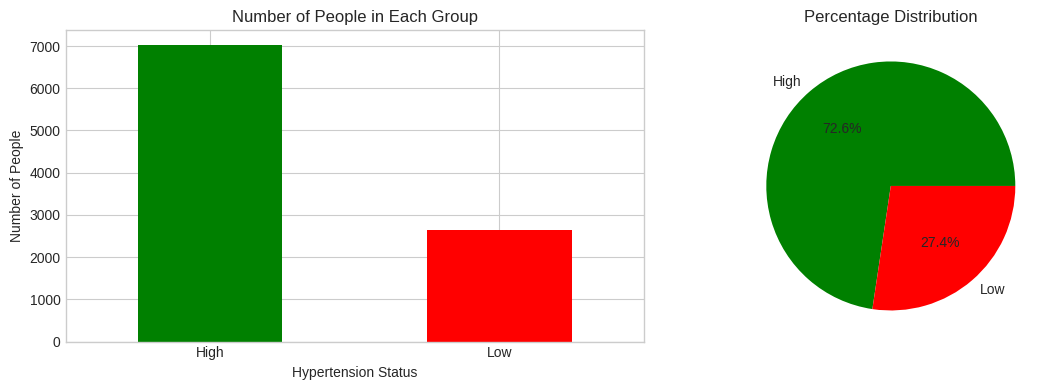

✓ Charts created


In [5]:
# Create two simple charts side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Chart 1: Bar chart showing counts
counts.plot(kind='bar', ax=ax1, color=['green', 'red'])
ax1.set_title('Number of People in Each Group')
ax1.set_xlabel('Hypertension Status')
ax1.set_ylabel('Number of People')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=0)

# Chart 2: Pie chart showing percentages
counts.plot(kind='pie', ax=ax2, autopct='%1.1f%%', colors=['green', 'red'])
ax2.set_title('Percentage Distribution')
ax2.set_ylabel('')

plt.tight_layout()
plt.show()

print("✓ Charts created")

**Step 6: Look at Age Distribution**

Age Statistics:
  Youngest person: 18 years old
  Oldest person: 89 years old
  Average age: 53.5 years old


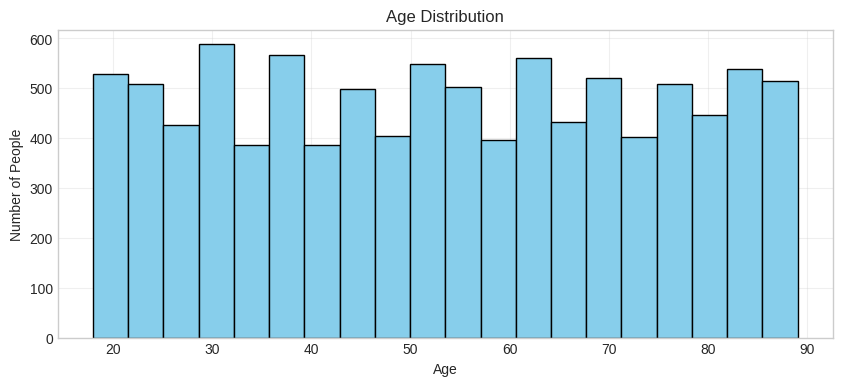

✓ Age chart created


In [6]:
# Show age statistics
print("Age Statistics:")
print(f"  Youngest person: {df['Age'].min()} years old")
print(f"  Oldest person: {df['Age'].max()} years old")
print(f"  Average age: {df['Age'].mean():.1f} years old")

# Create a simple histogram
plt.figure(figsize=(10, 4))
plt.hist(df['Age'], bins=20, color='skyblue', edgecolor='black')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Number of People')
plt.grid(True, alpha=0.3)
plt.show()

print("✓ Age chart created")

**Step 7: Look at Blood Pressure**

Blood Pressure Statistics:

Systolic (top number):
  Lowest: 90
  Highest: 179
  Average: 134.9

Diastolic (bottom number):
  Lowest: 60
  Highest: 119
  Average: 89.7


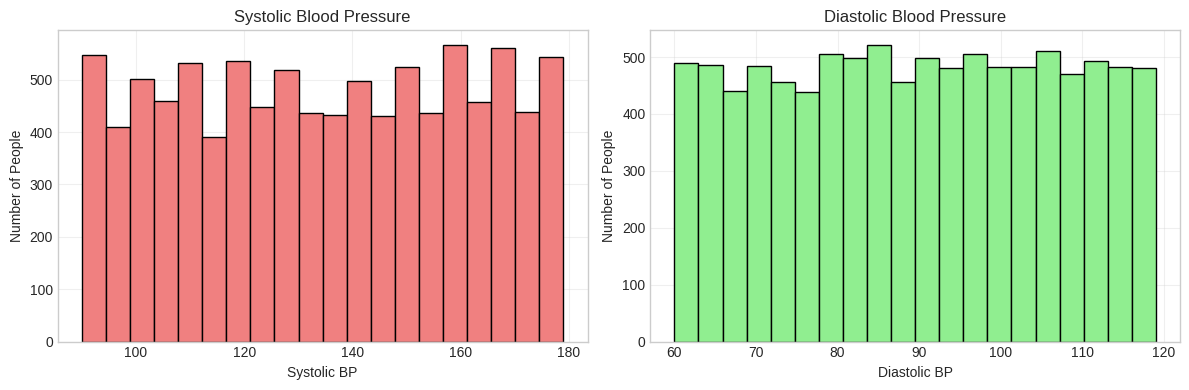

✓ Blood pressure charts created


In [7]:
# Show blood pressure statistics
print("Blood Pressure Statistics:")
print("\nSystolic (top number):")
print(f"  Lowest: {df['Systolic_BP'].min():.0f}")
print(f"  Highest: {df['Systolic_BP'].max():.0f}")
print(f"  Average: {df['Systolic_BP'].mean():.1f}")

print("\nDiastolic (bottom number):")
print(f"  Lowest: {df['Diastolic_BP'].min():.0f}")
print(f"  Highest: {df['Diastolic_BP'].max():.0f}")
print(f"  Average: {df['Diastolic_BP'].mean():.1f}")

# Create two side-by-side histograms
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.hist(df['Systolic_BP'], bins=20, color='lightcoral', edgecolor='black')
ax1.set_title('Systolic Blood Pressure')
ax1.set_xlabel('Systolic BP')
ax1.set_ylabel('Number of People')
ax1.grid(True, alpha=0.3)

ax2.hist(df['Diastolic_BP'], bins=20, color='lightgreen', edgecolor='black')
ax2.set_title('Diastolic Blood Pressure')
ax2.set_xlabel('Diastolic BP')
ax2.set_ylabel('Number of People')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Blood pressure charts created")

**Step 8: Correlation Matrix (How features relate to each other)**

Calculating correlations for 14 numerical features
Features: ['Age', 'BMI', 'Cholesterol', 'Systolic_BP', 'Diastolic_BP', 'Alcohol_Intake', 'Stress_Level', 'Salt_Intake', 'Sleep_Duration', 'Heart_Rate', 'LDL', 'HDL', 'Triglycerides', 'Glucose']



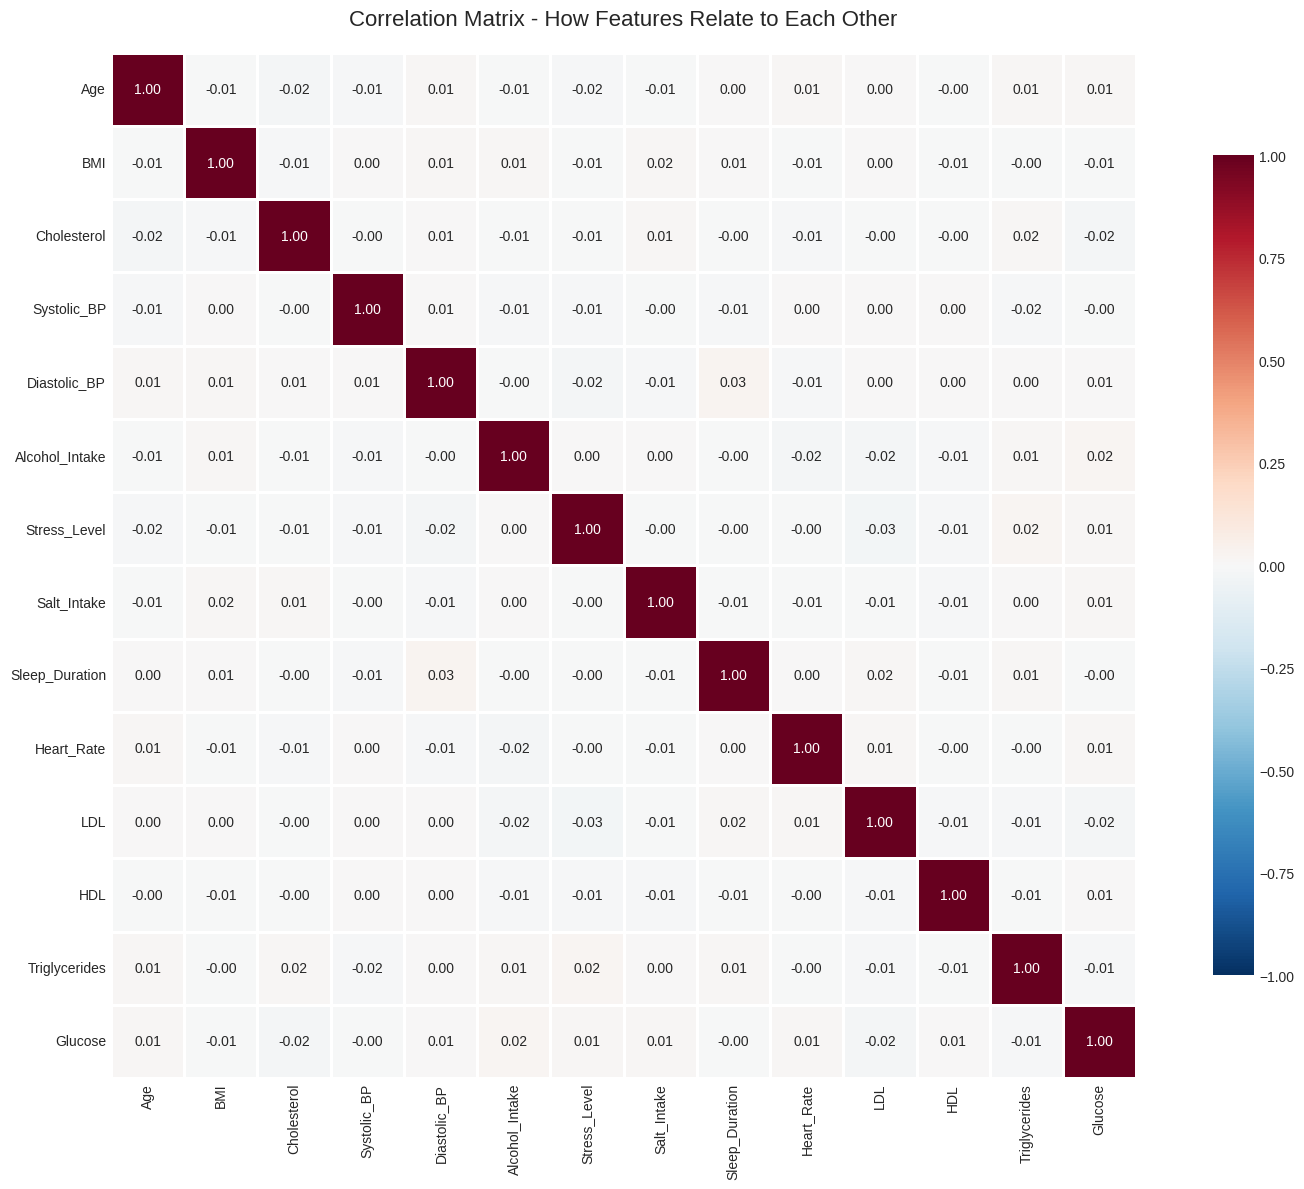


✓ Correlation matrix created

How to read this chart:
  🔴 Red = Positive correlation (both increase together)
  🔵 Blue = Negative correlation (one increases, other decreases)
  ⚪ White = No correlation (not related)

  Examples of strong correlations to look for:
  - Values close to +1.0 or -1.0 = very strong relationship
  - Values around ±0.5 to ±0.7 = moderate relationship
  - Values close to 0 = weak or no relationship


In [8]:
# Step 8a: Select only numerical columns for correlation
# (Correlation only works with numbers, not text)
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"Calculating correlations for {len(numerical_cols)} numerical features")
print(f"Features: {numerical_cols}\n")

# Step 8b: Calculate correlation (how features relate to each other)
# Values close to 1 = strong positive relationship
# Values close to -1 = strong negative relationship
# Values close to 0 = no relationship
correlation = df[numerical_cols].corr()

# Step 8c: Create a heatmap (color chart) to visualize correlations
plt.figure(figsize=(16, 12))
sns.heatmap(correlation,
            annot=True,  # Show numbers on the chart
            fmt='.2f',   # Show 2 decimal places
            cmap='RdBu_r',  # Red-Blue reversed colors (red=positive, blue=negative)
            center=0,    # Center the color scale at 0
            square=True,  # Make cells square-shaped
            linewidths=1,  # Add lines between cells
            cbar_kws={"shrink": 0.8},  # Make color bar smaller
            vmin=-1, vmax=1)  # Set scale from -1 to +1

plt.title('Correlation Matrix - How Features Relate to Each Other', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

print("\n✓ Correlation matrix created")
print("\nHow to read this chart:")
print("  🔴 Red = Positive correlation (both increase together)")
print("  🔵 Blue = Negative correlation (one increases, other decreases)")
print("  ⚪ White = No correlation (not related)")
print("\n  Examples of strong correlations to look for:")
print("  - Values close to +1.0 or -1.0 = very strong relationship")
print("  - Values around ±0.5 to ±0.7 = moderate relationship")
print("  - Values close to 0 = weak or no relationship")

**Step 8b: Find Strongest Correlations**

In [9]:
# Find the strongest correlations (excluding the diagonal which is always 1.0)
print("Top 10 Strongest Correlations:")
print("="*70)

# Get absolute values and remove diagonal
corr_pairs = correlation.abs().unstack()
corr_pairs = corr_pairs[corr_pairs < 1]  # Remove diagonal (perfect self-correlation)
corr_pairs = corr_pairs.sort_values(ascending=False)

# Show top 10 unique pairs
seen = set()
count = 0
for (var1, var2), value in corr_pairs.items():
    pair = tuple(sorted([var1, var2]))
    if pair not in seen:
        seen.add(pair)
        actual_corr = correlation.loc[var1, var2]
        direction = "positive" if actual_corr > 0 else "negative"
        print(f"{count+1}. {var1} ↔ {var2}")
        print(f"   Correlation: {actual_corr:.3f} ({direction})")
        count += 1
        if count >= 10:
            break

print("\n" + "="*70)
print("NOTE: Even these 'strongest' correlations are weak.")
print("This is EXPECTED and GOOD for our analysis!")
print("="*70)

Top 10 Strongest Correlations:
1. Sleep_Duration ↔ Diastolic_BP
   Correlation: 0.027 (positive)
2. LDL ↔ Stress_Level
   Correlation: -0.026 (negative)
3. Stress_Level ↔ Triglycerides
   Correlation: 0.022 (positive)
4. LDL ↔ Alcohol_Intake
   Correlation: -0.021 (negative)
5. Stress_Level ↔ Diastolic_BP
   Correlation: -0.021 (negative)
6. Age ↔ Cholesterol
   Correlation: -0.021 (negative)
7. Alcohol_Intake ↔ Glucose
   Correlation: 0.019 (positive)
8. Cholesterol ↔ Glucose
   Correlation: -0.018 (negative)
9. Glucose ↔ LDL
   Correlation: -0.016 (negative)
10. Alcohol_Intake ↔ Heart_Rate
   Correlation: -0.016 (negative)

NOTE: Even these 'strongest' correlations are weak.
This is EXPECTED and GOOD for our analysis!


**Step 9: Summary Statistics**

In [10]:
# Show summary of all numerical columns
print("Summary of Numerical Data:")
print("="*60)
print(df.describe().to_string())
print("="*60)
print("\nNote: This shows count, mean (average), std (spread), min, max, etc.")

Summary of Numerical Data:
               Age          BMI  Cholesterol  Systolic_BP  Diastolic_BP  Alcohol_Intake  Stress_Level  Salt_Intake  Sleep_Duration   Heart_Rate          LDL          HDL  Triglycerides      Glucose
count  9667.000000  9667.000000  9666.000000  9666.000000   9666.000000     9666.000000   9666.000000  9666.000000     9666.000000  9666.000000  9666.000000  9666.000000    9666.000000  9666.000000
mean     53.468398    27.474584   224.451273   134.920857     89.693462       14.896441      5.018001     8.520288        6.992096    74.643182   129.799193    64.288641     149.171633   134.818850
std      20.764713     7.227598    43.284568    26.058461     17.269031        8.696344      2.576283     3.748238        1.736859    14.407083    34.393197    20.204717      57.857547    37.421844
min      18.000000    15.000000   150.000000    90.000000     60.000000        0.000000      1.000000     2.000000        4.000000    50.000000    70.000000    30.000000      50.000

**Step 10: See What Features Look Like**

In [11]:
# Show first 10 rows to understand the data
print("First 10 rows of data:")
print("="*80)
df.head(10)

First 10 rows of data:


,Country,Age,BMI,Cholesterol,Systolic_BP,Diastolic_BP,Smoking_Status,Alcohol_Intake,Physical_Activity_Level,Family_History,...,Sleep_Duration,Heart_Rate,LDL,HDL,Triglycerides,Glucose,Gender,Education_Level,Employment_Status,Hypertension
0,UK,58,29.5,230.0,160.0,79.0,Never,27.9,Low,Yes,...,6.1,80.0,100.0,75.0,72.0,179.0,Female,Primary,Unemployed,High
1,Spain,34,36.2,201.0,120.0,84.0,Never,27.5,High,Yes,...,9.8,56.0,77.0,47.0,90.0,113.0,Male,Secondary,Unemployed,High
2,Indonesia,73,18.2,173.0,156.0,60.0,Current,1.8,High,Yes,...,5.2,75.0,162.0,56.0,81.0,101.0,Male,Primary,Employed,Low
3,Canada,60,20.3,183.0,122.0,94.0,Never,11.6,Moderate,Yes,...,7.5,71.0,164.0,93.0,94.0,199.0,Female,Secondary,Retired,High
4,France,73,21.8,296.0,91.0,97.0,Never,29.1,Moderate,Yes,...,5.0,52.0,108.0,74.0,226.0,157.0,Female,Primary,Employed,High
5,UK,44,31.5,293.0,158.0,118.0,Former,20.3,Moderate,No,...,8.1,98.0,81.0,69.0,181.0,85.0,Male,Tertiary,Employed,High
6,South Korea,88,30.9,263.0,118.0,62.0,Current,8.6,Low,Yes,...,4.0,88.0,114.0,52.0,139.0,194.0,Male,Secondary,Employed,Low
7,Canada,25,18.1,151.0,175.0,101.0,Never,16.6,Low,Yes,...,5.8,99.0,154.0,34.0,132.0,193.0,Female,Secondary,Employed,High
8,Canada,89,19.0,198.0,102.0,104.0,Former,10.5,Low,Yes,...,6.6,56.0,157.0,81.0,145.0,161.0,Female,Primary,Retired,Low
9,Brazil,33,39.1,268.0,168.0,98.0,Current,20.7,Moderate,No,...,8.0,76.0,89.0,37.0,223.0,164.0,Male,Primary,Retired,High
